#Model Training

This notebook uses the audio features extracted and trains different anomaly detection models.

## 0) Paths & Constants

In [44]:
# ── All paths and settings are defined here ──────────────────────────────────
MODELS_DIR    = "/content/drive/MyDrive/Final Project RMOT/artifacts/models"
RESULTS_DIR   = "/content/drive/MyDrive/Final Project RMOT/artifacts/results"

USE_AUGMENTED = True

if USE_AUGMENTED:
    PROCESSED_DIR = "/content/drive/MyDrive/Final Project RMOT/MIMII_dataset/processed/augmented"
else:
    PROCESSED_DIR = "/content/drive/MyDrive/Final Project RMOT/MIMII_dataset/processed/features"


import os
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Model hyperparameters ─────────────────────────────────────────────────────
CNN_EPOCHS        = 20
CNN_BATCH_SIZE    = 32
CNN_PATIENCE      = 5

TS_EPOCHS         = 20
TS_BATCH_SIZE     = 32
TS_PATIENCE       = 5

OCSVM_NU          = 0.1
ISO_N_ESTIMATORS  = 100
ISO_CONTAMINATION = 0.1
LOGREG_MAX_ITER   = 1000


###Mounting Google Drive

In [45]:
from google.colab import drive
drive.flush_and_unmount()

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Importing Extracted Features

In [47]:
import sys
import joblib

sys.path.append(PROCESSED_DIR)
sys.path.append(MODELS_DIR)


In [48]:
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

wav2vec_features = joblib.load(os.path.join(PROCESSED_DIR, 'extracted_wav2vec_features.joblib'))
ast_features     = joblib.load(os.path.join(PROCESSED_DIR, 'extracted_ast_features.joblib'))
logmel_features  = joblib.load(os.path.join(PROCESSED_DIR, 'extracted_logmel_features.joblib'))
labels           = joblib.load(os.path.join(PROCESSED_DIR, 'labels.joblib'))

print("All feature files loaded successfully.")

All feature files loaded successfully.


###Importing Models

In [49]:
from models import (
    get_ocsvm, get_isolation_forest, train_model, predict_model,
    get_anomaly_scores, build_cnn_model,
    build_teacher_student_models, train_teacher_student, predict_teacher_student,
    get_logistic_regression
)

In [50]:
y_train = labels["train"]
y_val = labels["val"]
y_test = labels["test"]

###Helper: Confusion Matrix


In [51]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot a confusion matrix for binary classification (Normal vs Anomaly)."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly']
    )
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


###Experimental

We are going to add all our feature extractions and models into seperate dictionary so we can pick which features we want to train each model on.

In [52]:
features = {
    "wav2vec": wav2vec_features,
    "ast":     ast_features,
    "logmel":  logmel_features
}

models = {
    "ocsvm":      get_ocsvm(nu=OCSVM_NU),
    "iso_forest": get_isolation_forest(n_estimators=ISO_N_ESTIMATORS, contamination=ISO_CONTAMINATION),
    "logreg":     get_logistic_regression(max_iter=LOGREG_MAX_ITER),
}


In this cell change the features or model.

In [53]:
SELECTED_FEATURES = ["wav2vec", "ast"]
SELECTED_MODELS = ["ocsvm", "iso_forest", "logreg"]

RUN_CNN = True
RUN_TEACHER_STUDENT = True


Training ocsvm on wav2vec...
Accuracy: 0.603, F1: 0.739, AUC: 0.5020885547201337
Inference: 0.002s total | 0.030ms per sample


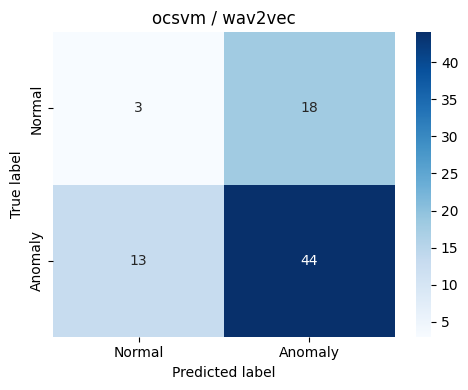


Training iso_forest on wav2vec...
Accuracy: 0.577, F1: 0.723, AUC: 0.5321637426900585
Inference: 0.011s total | 0.137ms per sample


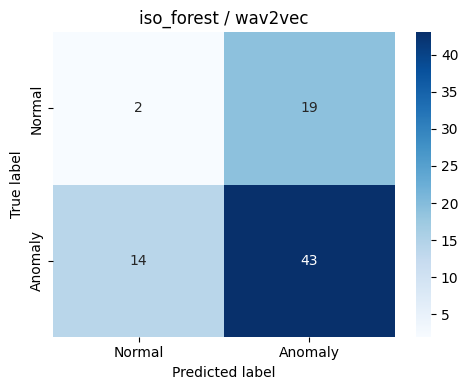


Training logreg on wav2vec...
Accuracy: 0.833, F1: 0.893, AUC: 0.7944862155388471
Inference: 0.001s total | 0.008ms per sample


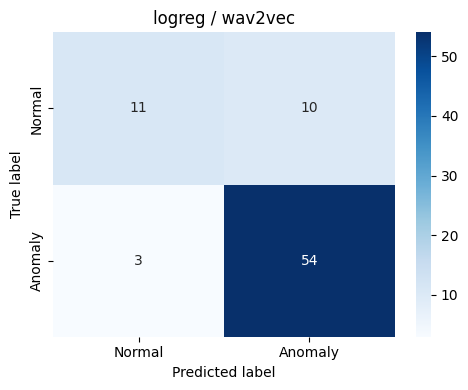


Training ocsvm on ast...
Accuracy: 0.846, F1: 0.898, AUC: 0.8454469507101086
Inference: 0.004s total | 0.051ms per sample


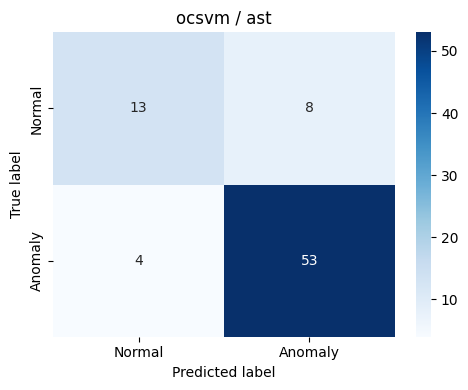


Training iso_forest on ast...
Accuracy: 0.846, F1: 0.897, AUC: 0.8387635756056808
Inference: 0.017s total | 0.216ms per sample


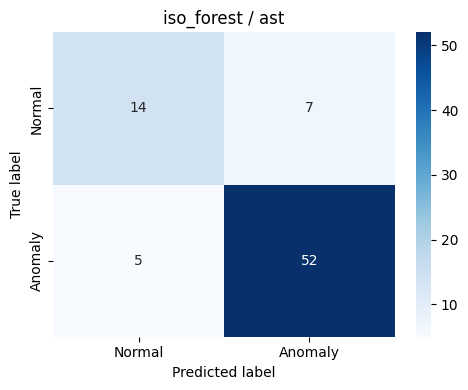


Training logreg on ast...
Accuracy: 0.936, F1: 0.958, AUC: 0.9799498746867168
Inference: 0.002s total | 0.026ms per sample


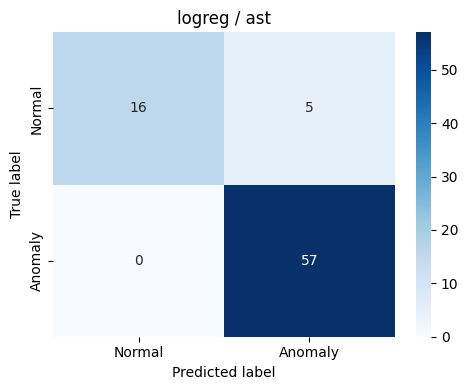

In [69]:
results     = {}
y_train_np  = np.array(y_train)
y_test_np   = np.array(y_test)
normal_mask = (y_train_np == 1)

UNSUPERVISED_MODELS = ["ocsvm", "iso_forest"]
SUPERVISED_MODELS   = ["logreg"]

for feature_name in SELECTED_FEATURES:
    X_train_data  = features[feature_name][f'{feature_name}_train_features']
    X_val_data    = features[feature_name][f'{feature_name}_val_features']
    X_test_data   = features[feature_name][f'{feature_name}_test_features']

    results[feature_name] = {}

    X_train_normal = X_train_data[normal_mask]

    for model_name in SELECTED_MODELS:
        print(f"\nTraining {model_name} on {feature_name}...")

        model = models[model_name]

        # ── Unsupervised models ────────────────────────────────────────────────
        if model_name in UNSUPERVISED_MODELS:
            model = train_model(model, X_train_normal)

            t0        = time.time()
            raw_preds = predict_model(model, X_test_data)
            latency_s = time.time() - t0

            preds = (raw_preds == 1).astype(int)

            try:
                if model_name == "ocsvm":
                    scores = model.decision_function(X_test_data)
                elif model_name == "iso_forest":
                    scores = model.score_samples(X_test_data)
                else:
                    scores = None
                if scores is not None:
                    auc = roc_auc_score(y_test_np, scores)
                    if auc < 0.5:
                        auc = 1 - auc
                else:
                    auc = None
            except:
                auc = None

        # ── Supervised models ──────────────────────────────────────────────────
        elif model_name in SUPERVISED_MODELS:
            model.fit(X_train_data, y_train_np)

            t0        = time.time()
            preds     = model.predict(X_test_data)
            latency_s = time.time() - t0

            try:
                scores = model.predict_proba(X_test_data)[:, 1]
                auc    = roc_auc_score(y_test_np, scores)
            except:
                auc = None

        else:
            print(f"Skipping unsupported model: {model_name}")
            continue

        assert len(preds) == len(y_test_np)

        # ── Save model checkpoint ──────────────────────────────────────────────
        ckpt_path = os.path.join(MODELS_DIR, f"{feature_name}_{model_name}.joblib")
        joblib.dump(model, ckpt_path)

        # ── Metrics & confusion matrix ─────────────────────────────────────────
        report = classification_report(
            y_test_np, preds,
            target_names=["Normal", "Anomaly"],
            output_dict=True, zero_division=0
        )
        acc = accuracy_score(y_test_np, preds)

        print(f"Accuracy: {acc:.3f}, F1: {report['Anomaly']['f1-score']:.3f}, AUC: {auc}")
        print(f"Inference: {latency_s:.3f}s total | {latency_s/len(y_test_np)*1000:.3f}ms per sample")

        plot_confusion_matrix(y_test_np, preds, title=f"{model_name} / {feature_name}")

        results[feature_name][model_name] = {
            "accuracy":          acc,
            "precision":         report["Anomaly"]["precision"],
            "recall":            report["Anomaly"]["recall"],
            "f1":                report["Anomaly"]["f1-score"],
            "auc":               auc,
            "latency_total_s":   latency_s,
            "latency_ms_sample": latency_s / len(y_test_np) * 1000,
        }

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128)
X_train_flat_reduced  = pca.fit_transform(X_train_flat)
X_test_flat_reduced   = pca.transform(X_test_flat)
X_train_normal_reduced = X_train_flat_reduced[normal_mask]

print("Reduced input_dim:", X_train_flat_reduced.shape[1])

teacher, student = build_teacher_student_models(input_dim=X_train_flat_reduced.shape[1])

student = train_teacher_student(
    teacher, student, X_train_normal_reduced,
    epochs=TS_EPOCHS, batch_size=TS_BATCH_SIZE, patience=TS_PATIENCE
)

preds, scores, threshold = predict_teacher_student(
    teacher, student, X_train_normal_reduced, X_test_flat_reduced
)

Reduced input_dim: 128
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 494.7731 - val_loss: 384.9690
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 338.8543 - val_loss: 275.0445
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 262.9141 - val_loss: 247.1011
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 221.3306 - val_loss: 235.1133
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 202.9146 - val_loss: 223.2061
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 185.9703 - val_loss: 211.4746
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 169.4549 - val_loss: 202.2847
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 155.6820 - val_loss: 197.1411
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 144.8777 - val_loss: 190.2911
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 133.8607 - val_loss: 186.5181
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 124.7544 - val_loss: 180.4979
Epoch 12/20
8/8 ━━

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 309.9053 - val_loss: 39.2515
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 33.9419 - val_loss: 22.5632
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 18.0406 - val_loss: 14.3633
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 13.8681 - val_loss: 13.9231
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 11.9996 - val_loss: 12.0481
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 11.2420 - val_loss: 11.6639
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.8859 - val_loss: 11.0782
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.7412 - val_loss: 11.0071
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 10.6872 - val_loss: 10.9643
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.3562 - val_loss: 10.9647
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11.0098 - val_loss: 12.1967
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.0

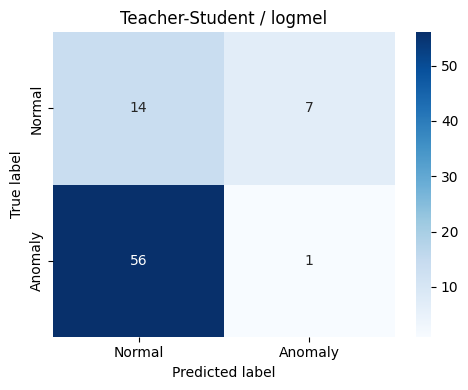

Teacher-Student on logmel -> Accuracy: 0.192, F1: 0.308, AUC: 0.440


In [72]:
if RUN_TEACHER_STUDENT and "logmel" in features:
    from tensorflow import keras

    X_train = features["logmel"]["logmel_train_features"]
    X_test  = features["logmel"]["logmel_test_features"]

    X_train_flat   = X_train.reshape(len(X_train), -1)
    X_test_flat    = X_test.reshape(len(X_test),   -1)
    X_train_normal = X_train_flat[normal_mask]

    teacher, student = build_teacher_student_models(input_dim=X_train_flat.shape[1])

    t0 = time.time()
    student = train_teacher_student(
        teacher, student, X_train_normal,
        epochs=TS_EPOCHS, batch_size=TS_BATCH_SIZE, patience=TS_PATIENCE
    )
    train_time = time.time() - t0

    # Save model checkpoint
    student.save(os.path.join(MODELS_DIR, "teacher_student_logmel.keras"))

    t0 = time.time()
    preds, scores, threshold = predict_teacher_student(
        teacher, student, X_train_normal, X_test_flat
    )
    latency_s = time.time() - t0

    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    print(f"Teacher-Student training time: {train_time:.1f}s")
    print(f"Inference: {latency_s:.3f}s total | {latency_s/len(y_test)*1000:.3f}ms per sample")

    plot_confusion_matrix(y_test, preds, title="Teacher-Student / logmel")

    results.setdefault("logmel", {})
    results["logmel"]["teacher_student"] = {
        "accuracy":          accuracy_score(y_test, preds),
        "precision":         report["0"]["precision"],
        "recall":            report["0"]["recall"],
        "f1":                report["0"]["f1-score"],
        "auc":               roc_auc_score(y_test, scores),
        "threshold":         threshold,
        "latency_total_s":   latency_s,
        "latency_ms_sample": latency_s / len(y_test) * 1000,
    }

    print(
        f"Teacher-Student on logmel -> "
        f"Accuracy: {results['logmel']['teacher_student']['accuracy']:.3f}, "
        f"F1: {results['logmel']['teacher_student']['f1']:.3f}, "
        f"AUC: {results['logmel']['teacher_student']['auc']:.3f}"
    )

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.6006 - loss: 1.2975 - val_accuracy: 0.2564 - val_loss: 0.8522
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.6556 - loss: 0.6488 - val_accuracy: 0.8590 - val_loss: 0.5337
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.7686 - loss: 0.5384 - val_accuracy: 0.8718 - val_loss: 0.5182
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.8375 - loss: 0.4746 - val_accuracy: 0.8718 - val_loss: 0.3745
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.8678 - loss: 0.3795 - val_accuracy: 0.8846 - val_loss: 0.3358
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.8733 - loss: 0.3300 - val_accuracy: 0.8974 - val_loss: 0.3254
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.8788 - loss: 0.3092 - val_accuracy: 0.7821 - val_loss: 0.4346
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.8815 - loss: 0.3237 - val_accuracy: 0.

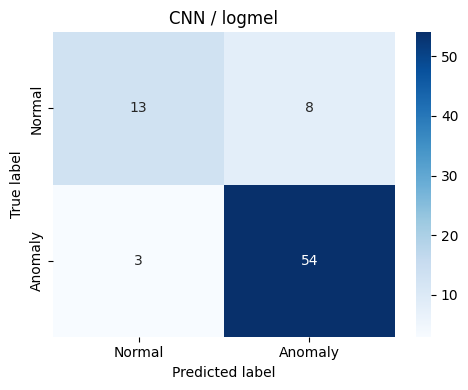

CNN on logmel -> Accuracy: 0.859, F1: 0.703, AUC: 0.905


In [73]:
if RUN_CNN and "logmel" in features:
    from tensorflow import keras

    X_train = np.array(features["logmel"]["logmel_train_features"], dtype=np.float32)
    X_val   = np.array(features["logmel"]["logmel_val_features"], dtype=np.float32)
    X_test  = np.array(features["logmel"]["logmel_test_features"], dtype=np.float32)

    y_train = np.array(y_train)
    y_val   = np.array(y_val)
    y_test  = np.array(y_test)


    if len(X_train.shape) == 3:
        X_train = X_train[..., np.newaxis]
        X_val   = X_val[..., np.newaxis]
        X_test  = X_test[..., np.newaxis]

    cnn_model = build_cnn_model(input_shape=X_train.shape[1:])

    # Early stopping + model checkpoint
    es = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=CNN_PATIENCE, restore_best_weights=True
    )
    mc = keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "cnn_logmel_best.keras"),
        monitor='val_loss', save_best_only=True
    )

    t0 = time.time()
    cnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CNN_EPOCHS,
        batch_size=CNN_BATCH_SIZE,
        callbacks=[es, mc],
        verbose=1
    )
    train_time = time.time() - t0
    print(f"CNN training time: {train_time:.1f}s")

    t0    = time.time()
    probs = cnn_model.predict(X_test).ravel()
    latency_s = time.time() - t0

    preds = (probs >= 0.5).astype(int)

    print(f"Inference: {latency_s:.3f}s total | {latency_s/len(y_test)*1000:.3f}ms per sample")

    plot_confusion_matrix(y_test, preds, title="CNN / logmel")

    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    results.setdefault("logmel", {})
    results["logmel"]["cnn"] = {
        "accuracy":          accuracy_score(y_test, preds),
        "precision":         report["0"]["precision"],
        "recall":            report["0"]["recall"],
        "f1":                report["0"]["f1-score"],
        "auc":               roc_auc_score(y_test, probs),
        "latency_total_s":   latency_s,
        "latency_ms_sample": latency_s / len(y_test) * 1000,
    }

    print(
        f"CNN on logmel -> "
        f"Accuracy: {results['logmel']['cnn']['accuracy']:.3f}, "
        f"F1: {results['logmel']['cnn']['f1']:.3f}, "
        f"AUC: {results['logmel']['cnn']['auc']:.3f}"
    )


### Saving Model Results

In [74]:
from datetime import datetime

current_date = datetime.now().strftime("%Y-%m-%d")

all_results_data = []

for feature_name, model_results in results.items():
    for model_name, metrics in model_results.items():
        row = {
            'date':              current_date,
            'feature_type':      feature_name,
            'model_trained':     model_name,
            'accuracy':          metrics.get('accuracy'),
            'precision':         metrics.get('precision'),
            'recall':            metrics.get('recall'),
            'f1_score':          metrics.get('f1'),
            'auc':               metrics.get('auc'),
            'latency_total_s':   metrics.get('latency_total_s'),
            'latency_ms_sample': metrics.get('latency_ms_sample'),
        }
        all_results_data.append(row)

df_results = pd.DataFrame(all_results_data)

results_filename = os.path.join(RESULTS_DIR, f"model_training_results_{current_date}.csv")
df_results.to_csv(results_filename, index=False)

print(f"Model training results saved to: {results_filename}")
display(df_results)

Model training results saved to: /content/drive/MyDrive/Final Project RMOT/artifacts/results/model_training_results_2026-04-29.csv


,date,feature_type,model_trained,accuracy,precision,recall,f1_score,auc,latency_total_s,latency_ms_sample
0,2026-04-29,wav2vec,ocsvm,0.602564,0.709677,0.771930,0.739496,0.502089,0.002354,0.030181
1,2026-04-29,wav2vec,iso_forest,0.576923,0.693548,0.754386,0.722689,0.532164,0.010683,0.136962
2,2026-04-29,wav2vec,logreg,0.833333,0.843750,0.947368,0.892562,0.794486,0.000625,0.008015
3,2026-04-29,ast,ocsvm,0.846154,0.868852,0.929825,0.898305,0.845447,0.003968,0.050875
4,2026-04-29,ast,iso_forest,0.846154,0.881356,0.912281,0.896552,0.838764,0.016886,0.216481
5,2026-04-29,ast,logreg,0.935897,0.919355,1.000000,0.957983,0.979950,0.002000,0.025642
6,2026-04-29,logmel,teacher_student,0.192308,0.200000,0.666667,0.307692,0.440267,0.616914,7.909154
7,2026-04-29,logmel,cnn,0.858974,0.812500,0.619048,0.702703,0.904762,0.305022,3.910545


In [75]:
print(results.keys())
print(results.get("logmel", "logmel not in results"))

dict_keys(['wav2vec', 'ast', 'logmel'])
{'teacher_student': {'accuracy': 0.19230769230769232, 'precision': 0.2, 'recall': 0.6666666666666666, 'f1': 0.3076923076923077, 'auc': np.float64(0.44026733500417714), 'threshold': np.float32(0.97123605), 'latency_total_s': 0.6169140338897705, 'latency_ms_sample': 7.9091542806380835}, 'cnn': {'accuracy': 0.8589743589743589, 'precision': 0.8125, 'recall': 0.6190476190476191, 'f1': 0.7027027027027027, 'auc': np.float64(0.9047619047619048), 'latency_total_s': 0.3050224781036377, 'latency_ms_sample': 3.910544591072278}}
